# Analyze Nanostring data

This notebook uses `Lung5_Rep2` as an example to walk through a complete NanoString workflow in OmicVerse: loading the data, inspecting the spatial layout across FOVs, checking segmentation quality, and then learning graph embeddings with CAST for downstream clustering.

The analysis is organized into four parts:

1. Set up the environment and confirm the input file structure.
2. Read the NanoString dataset and inspect spatial coordinates and expression patterns.
3. Zoom in on a single FOV to examine image overlays and segmentation boundaries.
4. Prepare CAST inputs, generate embeddings, and compare clustering results in spatial space.

The goal is not only to run the pipeline, but also to understand why each step appears where it does and what the key parameters control.

## 1. Environment setup

This section does three things: import `omicverse`, set the plotting font, and enable auto-reload.

- `ov.style(font_path='Arial')`: keeps the plotting style consistent and avoids font mismatches in exported figures.
- `%autoreload 2`: useful during local development or package debugging, because edited source code is picked up when the cell is rerun.
- `Path`: used later to build data paths in a readable way.

In [1]:
from pathlib import Path
import omicverse as ov
ov.style(font_path='Arial')

# Enable auto-reload for development
%load_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA A100-SXM4-40GB
      Memory: 39.4 GB | Compute: 8.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.10rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



This line initializes the mixed CPU/GPU runtime used by OmicVerse.

For most users, the practical purpose is simple: later steps that involve deep learning or graph embedding can access hardware resources more reliably. If no GPU is available in the current environment, CAST should be configured to run on CPU instead.

In [ ]:
ov.settings.cpu_gpu_mixed_init()

## 2. Check the NanoString data directory

Before reading the data, print the directory tree and confirm that the expression matrix, metadata, and FOV coordinate files are all present where expected.

This is a small step, but it prevents a common source of errors: incorrect paths are often easier to fix at the file level than after a loader function fails.

We download the count data and HE image from https://nanostring.com/products/cosmx-spatial-molecular-imager/ffpe-dataset/

In [ ]:
# !mkdir data
# !mkdir data/nanostring_data
# !wget -P data/nanostring_data https://nanostring-public-share.s3.us-west-2.amazonaws.com/SMI-Compressed/Lung5_Rep2/Lung5_Rep2+SMI+Flat+data.tar.gz
# !tar -xzf data/nanostring_data/Lung5_Rep2+SMI+Flat+data.tar.gz -C data/nanostring_data/

In [4]:
ov.utils.print_tree(Path("data/nanostring_data/Lung5_Rep2/Lung5_Rep2-Flat_files_and_images"),)

Lung5_Rep2-Flat_files_and_images/
│   CellComposite/
│   ├── CellComposite_F001.jpg
│   ├── ...
│   └── CellComposite_F030.jpg
│   CellLabels/
│   ├── CellLabels_F001.tif
│   ├── ...
│   ├── CellLabels_F030.tif
│   └── Thumbs.db
│   CellOverlay/
│   ├── CellOverlay_F001.jpg
│   ├── ...
│   └── CellOverlay_F030.jpg
│   CompartmentLabels/
│   ├── CompartmentLabels_F001.tif
│   ├── ...
│   └── CompartmentLabels_F030.tif
├── Lung5_Rep2_exprMat_file.csv
├── Lung5_Rep2_fov_positions_file.csv
├── Lung5_Rep2_metadata_file.csv
└── Lung5_Rep2_tx_file.csv


## 3. Read the NanoString dataset

This cell builds an `AnnData` object with `ov.io.read_nanostring()`. Once loaded, the expression matrix, cell metadata, FOV annotations, and spatial coordinates are organized into `adata`.

### Main parameters

- `path`: directory containing the sample files.
- `counts_file`: expression matrix file, usually arranged as cells × genes.
- `meta_file`: metadata file with cell-level annotations.
- `fov_file`: file describing the spatial positions of different fields of view.

In practice, `read_nanostring()` is the entry point that converts raw NanoString outputs into a structure that can be used directly for plotting and downstream analysis.

In [5]:
from pathlib import Path
nanostring_dir = Path().resolve() / "data" / "nanostring_data"
sample_dir = nanostring_dir / "Lung5_Rep2" / "Lung5_Rep2-Flat_files_and_images"

adata = ov.io.read_nanostring(
    path=sample_dir,
    counts_file="Lung5_Rep2_exprMat_file.csv",
    meta_file="Lung5_Rep2_metadata_file.csv",
    fov_file="Lung5_Rep2_fov_positions_file.csv",
)

[Nanostring] Reading Nanostring data from: /scratch/users/steorra/analysis/26_omic_protocol/data/nanostring_data/Lung5_Rep2/Lung5_Rep2-Flat_files_and_images
[Nanostring] Matched cells: 106660
[Nanostring] Loading optional FOV images




00%|██████████| 31/31 [00:04<00:00,  7.59it/s]

[Nanostring] Extracted cell contours from CellLabels images (geometry WKT generated for 106660 cells)
[Nanostring] Loading FOV metadata: Lung5_Rep2_fov_positions_file.csv
[Nanostring] Done (n_obs=106660, n_vars=980)


## 4. Inspect the spatial layout at the whole-sample level

Here `ov.pl.embedding()` is used for a first overview across all FOVs.

### Main parameters

- `basis='spatial_fov'`: use the stitched spatial coordinate system across FOVs. This is the right view when you want to inspect how multiple FOVs are positioned relative to one another.
- `color=['Max.PanCK', 'fov']`: plot one panel by marker intensity and one by FOV identity.
- `vmax='p99.2'`: cap the color scale at the 99.2th percentile to reduce the influence of extreme values.
- `cmap='Reds'`: use a continuous red colormap for expression intensity.
- `wspace=0.35`: adjust spacing between panels.

At this stage, the aim is not fine detail. It is simply to confirm that coordinates, FOV stitching, and signal ranges look reasonable before moving to local inspection.

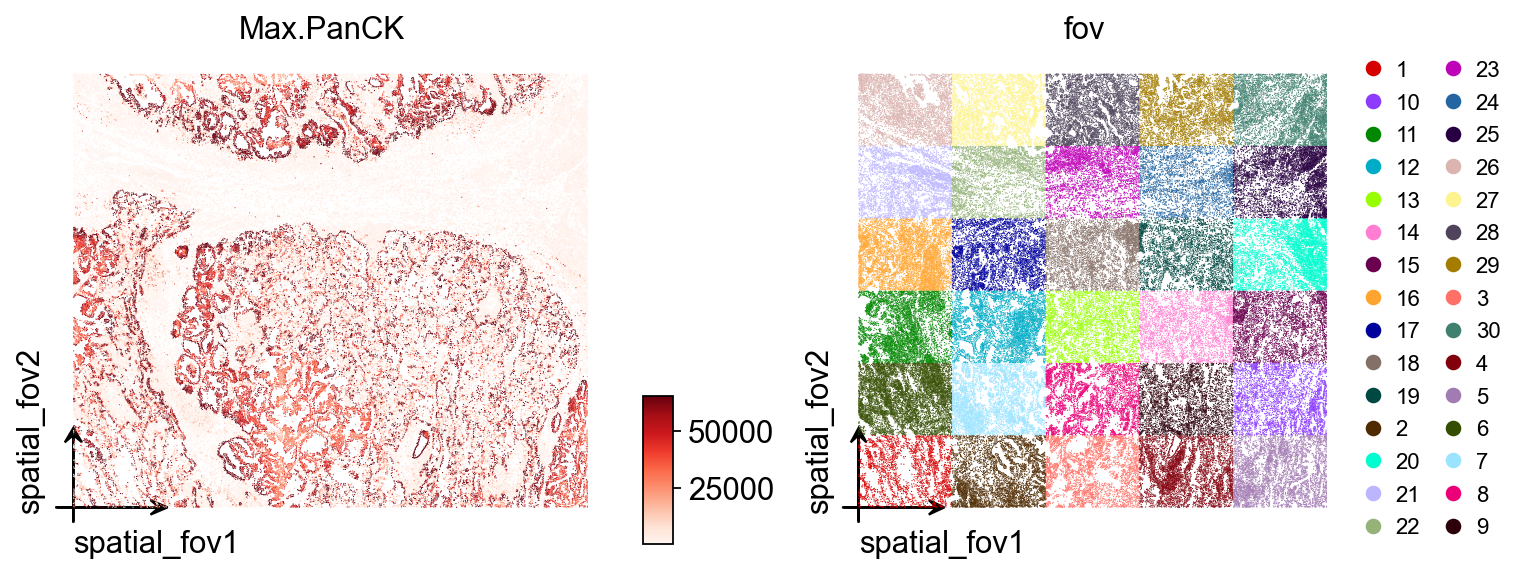

In [48]:
ov.pl.embedding(
    adata,
    basis='spatial_fov',
    color=['Max.PanCK','fov'],
    vmax='p99.2',
    cmap='Reds',
    wspace=0.35
)

Printing `adata` is a quick sanity check that the dataset loaded correctly. The most useful things to confirm here are:

- the number of observations and variables, that is, cells and features;
- which metadata columns are available in `obs`;
- whether `obsm`, `layers`, and `uns` contain the spatial objects needed for downstream analysis.

In [6]:
adata

AnnData object with n_obs × n_vars = 106660 × 980
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'geometry'
    uns: 'spatial', 'omicverse_io'
    obsm: 'spatial', 'spatial_fov'

## 5. Select a single FOV for local inspection

From this point on, the notebook focuses on `fov == '12'`. The reason is practical: a whole-sample view is useful for orientation, but a single FOV is much easier to read when checking coordinates, segmentation boundaries, and local expression structure.

To inspect a different field of view, replace `'12'` with the target FOV identifier.

In [7]:
vdata=adata[adata.obs['fov']=='12']

First, inspect the spatial distribution of `Max.PanCK` within a single FOV.

The important distinction here is between `basis='spatial'` and the earlier `spatial_fov`:

- `spatial_fov`: better for stitched, whole-sample views across multiple FOVs.
- `spatial`: better for the original local coordinate system within one FOV.

If the orientation, aspect ratio, or point placement of an individual FOV looks unusual, this is usually the first place to diagnose it.

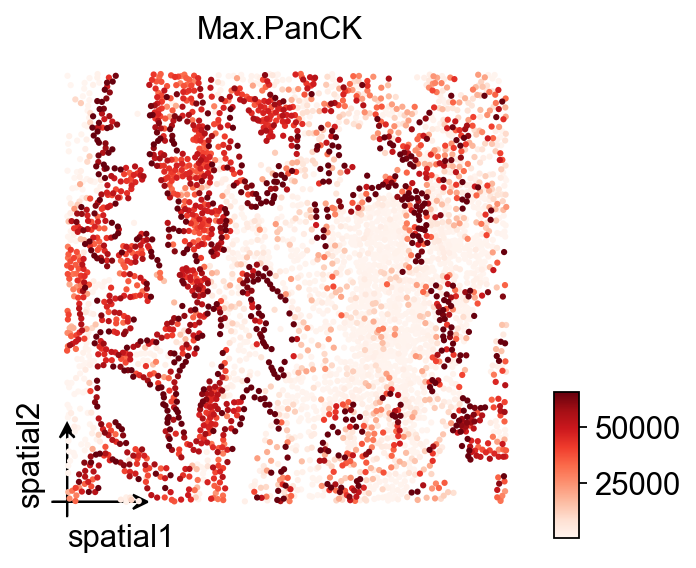

In [8]:
ov.pl.embedding(
    vdata,
    basis='spatial',
    color='Max.PanCK',
    vmax='p99.2',
    cmap='Reds'
)

## 6. Visualize a single FOV with the background image

`ov.pl.spatial()` overlays the signal on the spatial background image. Compared with a plain scatter plot, this gives a more tissue-like view of the data.

### Main parameters

- `color=[None, 'Max.PanCK']`: the first panel shows only the background image, and the second overlays the selected marker. This side-by-side setup makes the correspondence easier to read.
- `size=100`: controls the size of plotted markers.
- `library_id='12'`: explicitly selects the current FOV image.
- `img_key='hires'`: use the high-resolution image stored for this library.
- `alpha_img=1`: set image opacity. A value of 1 keeps the image fully visible.
- `crop_coord=None`: do not crop; display the full FOV.

When working on figure preparation, this step is useful for checking whether the signal pattern matches the image context before adding segmentation contours.

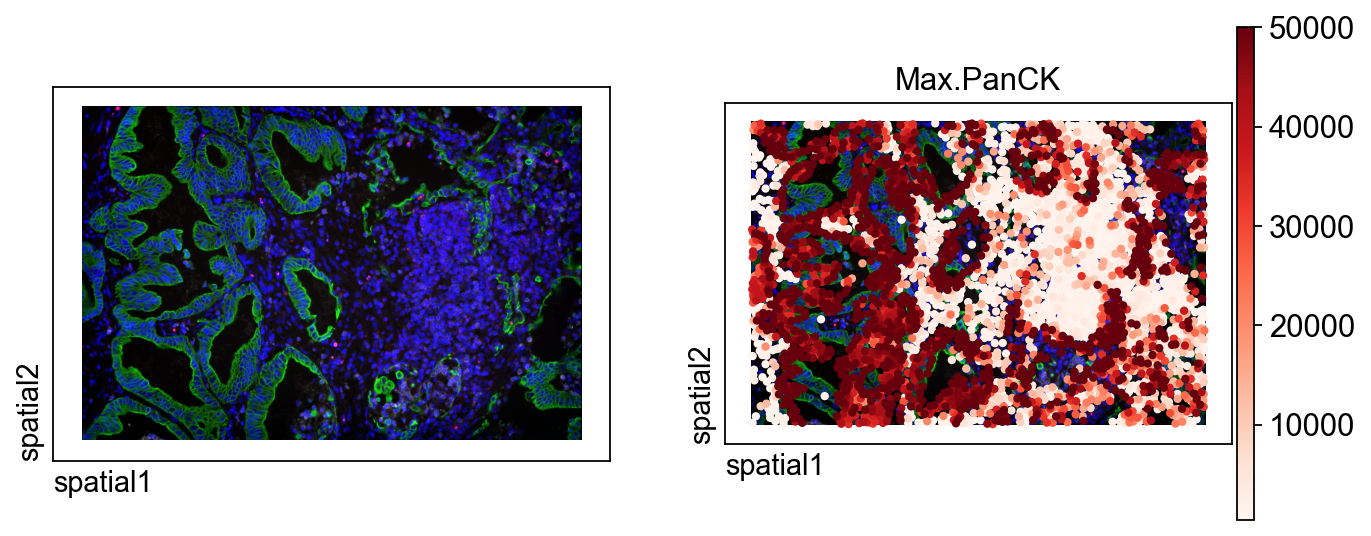

In [15]:
ov.pl.spatial(
    vdata, color=[None,"Max.PanCK"],
    size=100,
    library_id='12',
    legend_fontsize=13, 
    frameon=None,
    vmax=50000,
    cmap='Reds'
)

## 7. Inspect segmentation contours together with expression

Next, switch to `ov.pl.spatialseg()`. This function is more suitable for datasets with segmentation information because it overlays cell boundaries on the image rather than only plotting points.

### Main parameters

- `color='Max.PanCK'`: color cells by the selected feature.
- `edges_color='white'`, `edges_width=0`: control segmentation boundary color and line width.
- `seg_contourpx=15`: thickness of the segmentation contour in pixels.
- `library_id='12'`: choose the FOV to display.
- `img_key='hires'`: use the high-resolution background image.
- `crop_coord=None`: show the full field rather than a cropped region.

This is a good checkpoint for deciding whether the segmentation overlay is visually informative and whether boundary thickness is appropriate for the current figure scale.

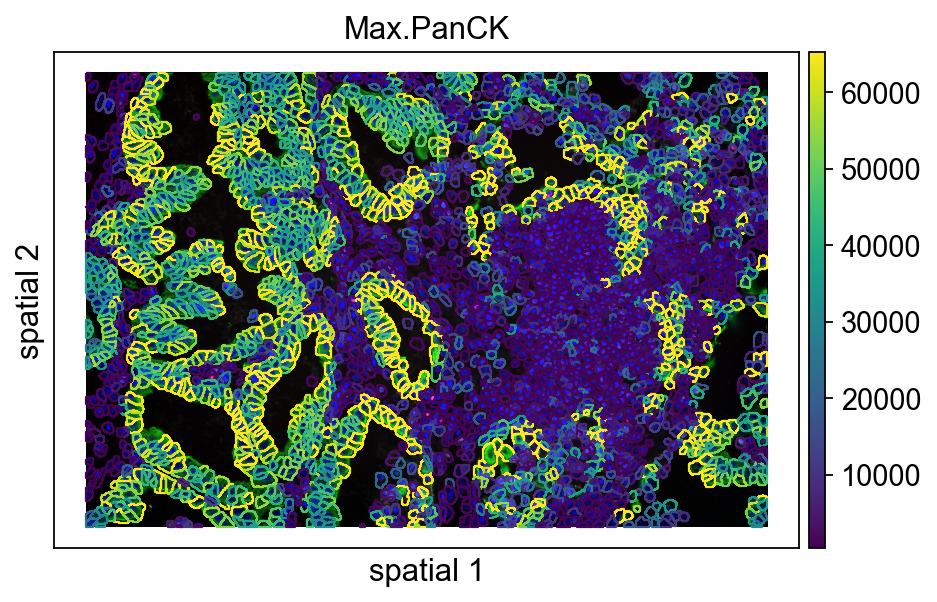

<Axes: title={'center': 'Max.PanCK'}, xlabel='spatial 1', ylabel='spatial 2'>

In [17]:
ov.pl.spatialseg(
    vdata,
    color="Max.PanCK",
    edges_color='white',
    edges_width=0,
    #edges_width=0.4,
    figsize=(7, 4),
    library_id='12',
    alpha_img=1,
    seg_contourpx=1,
    alpha=1,
    #crop_coord=(0, 0, 1400, 1400),
    legend_fontsize=13,
)

The next plot is similar to the previous one, except that `seg_contourpx` is no longer set explicitly. Looking at the two versions side by side makes it easier to judge how much the contour thickness affects readability.

A practical rule of thumb:

- if you want to emphasize segmentation structure, increase `seg_contourpx`;
- if you want to emphasize continuous expression patterns, use thinner boundaries or weaken them visually.

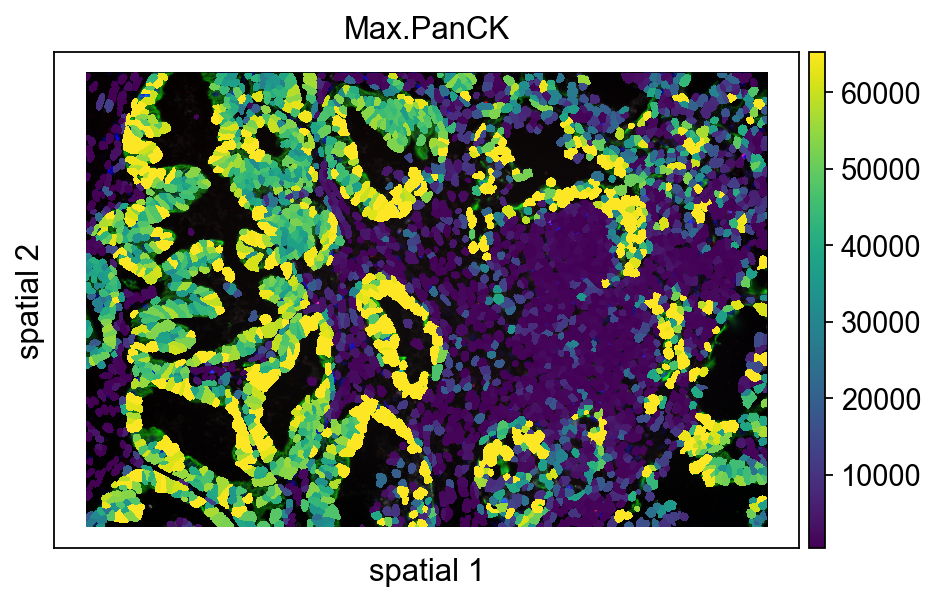

<Axes: title={'center': 'Max.PanCK'}, xlabel='spatial 1', ylabel='spatial 2'>

In [18]:
ov.pl.spatialseg(
    vdata,
    color="Max.PanCK",
    edges_color='white',
    edges_width=0,
    #edges_width=0.4,
    figsize=(7, 4),
    library_id='12',
    alpha_img=1,
    #seg_contourpx=1,
    alpha=1,
    #crop_coord=(0, 0, 1400, 1400),
    legend_fontsize=13,
)

## 8. Check coordinate ranges before local cropping

Before making a zoomed-in view, inspect the x and y coordinate ranges of the current FOV. This makes it easier to define `crop_coord` based on real values rather than trial and error.

It is a small step, but very helpful when preparing publication figures or when trying to isolate a specific local region.

In [21]:
vdata.obsm['spatial'][:,0].min(),vdata.obsm['spatial'][:,0].max()

(array(13), array(5456))

This cell prints the y-coordinate range separately so that, together with the previous output, a local crop window can be chosen more deliberately.

In [22]:
vdata.obsm['spatial'][:,1].min(),vdata.obsm['spatial'][:,1].max()

(array(9), array(3634))

## 9. Zoom in on a selected region

This cell uses `crop_coord=(0, 2000, 400, 2400)` to display a local region. In practice, you can think of this as defining a rectangular window within the current FOV so that cell boundaries and expression patterns are easier to inspect at higher resolution.

### What `crop_coord` does

Different plotting functions may implement coordinate order slightly differently internally, but the main idea is the same: supply a rectangular range and only display content inside it.

For image-based plots, cropping is especially useful when:

- a region of interest occupies only a small portion of the full FOV;
- segmentation quality needs to be assessed locally;
- figure panels require a tighter composition than the full image.

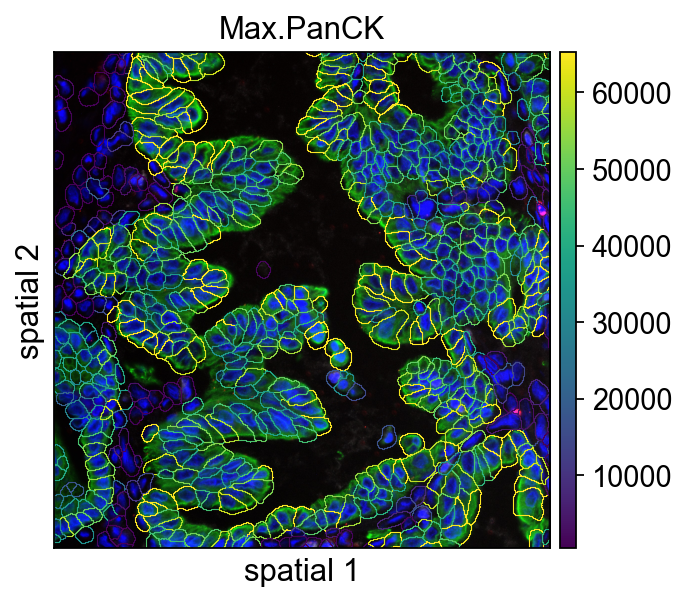

<Axes: title={'center': 'Max.PanCK'}, xlabel='spatial 1', ylabel='spatial 2'>

In [35]:
ov.pl.spatialseg(
    vdata,
    color="Max.PanCK",
    edges_color='white',
    edges_width=0,
    #edges_width=0.4,
    figsize=(7, 4),
    library_id='12',
    alpha_img=1,
    seg_contourpx=0.5,
    alpha=1,
    crop_coord=(0, 2000, 400, 2400),
    legend_fontsize=13,
)

Print `adata` again as a light sanity check before moving into the modeling part. The goal is simply to confirm that the visualization steps above did not introduce unexpected changes to the object state.

In [38]:
adata

AnnData object with n_obs × n_vars = 106660 × 980
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'geometry'
    uns: 'spatial', 'omicverse_io'
    obsm: 'spatial', 'spatial_fov'

## 10. Prepare spatial coordinates for CAST

CAST expects explicit coordinate inputs, so here the whole-sample coordinates from `spatial_fov` are written into `adata.obs['x']` and `adata.obs['y']`.

The original note already hints that this assignment may need to be rerun occasionally and checked for `NA` values. In practice, that usually means one of two things:

- the object state was not fully refreshed in a previous step;
- the index alignment was not what you expected.

The purpose of this cell is to make the coordinates easy to access later when building the per-FOV dictionaries required by CAST.

In [49]:
#This step sometimes needs to be run twice
#and you need to check that adata.obs['X'] is correctly assigned instead of NA
adata.obs['x'] = adata.obsm['spatial_fov'][:,0]
adata.obs['y'] = adata.obsm['spatial_fov'][:,1]
adata.obs['x'][0]

8156.0

## 11. Build a normalized expression layer

Here `ov.pp.normalize_total()` scales each cell to a total count of `1e4` and stores the result in `adata.layers['norm_1e4']`.

### Main parameters

- `target_sum=1e4`: the target total count after normalization for each cell.
- `inplace=False`: return the normalized matrix instead of overwriting the original data in place.

Keeping a separate normalized layer is useful because it preserves the raw matrix while creating a standardized input for downstream embedding methods.

In [50]:
adata.layers['norm_1e4'] = ov.pp.normalize_total(adata, target_sum=1e4, 
                                                 inplace=False)['X'].toarray() # we use normalized counts for each cell as input gene expression



🔍 Count Normalization:
   Target sum: 10000.0
   Exclude highly expressed: False
   ⚠️ Warning: 5,508 cells have zero counts

✅ Count Normalization Completed Successfully!
   ✓ Processed: 106,660 cells × 980 genes
   ✓ Runtime: 0.21s


## 12. Organize CAST inputs by FOV

CAST expects two dictionaries:

- `coords_raw`: two-dimensional coordinates for each FOV;
- `exp_dict`: normalized expression matrices for each FOV.

The key idea is to split one large `AnnData` object into multiple FOV-level subsets and then pass them to CAST for cross-sample graph representation learning. `samples = np.unique(adata.obs['fov'])` is used here to iterate over all available FOVs in a consistent order.

In [51]:
import numpy as np
# Get the coordinates and expression data for each sample
samples = np.unique(adata.obs['fov']) # used samples in adata
coords_raw = {
    sample_t: np.array(adata.obs[['x','y']])[adata.obs['fov'] == sample_t] for sample_t in samples
}
exp_dict = {
    sample_t: adata[adata.obs['fov'] == sample_t].layers['norm_1e4'] for sample_t in samples
}

## 13. Run CAST_MARK to generate graph embeddings

This is the main modeling step of the notebook: learn graph embeddings from the spatial coordinates and expression matrix of each FOV.

### Main parameters

- `coords_raw`: dictionary of spatial coordinates for each FOV.
- `exp_dict`: dictionary of expression matrices for each FOV.
- `output_path`: directory where intermediate results or saved outputs are written.
- `graph_strategy='delaunay'`: use Delaunay triangulation to define the spatial graph.
- `device='cuda:0'`: run on the first GPU. Change this if you need CPU or another device.
- `args = Args(...)`: package a group of training hyperparameters used by CAST.

The exact optimization details belong to CAST itself, but from the notebook perspective, this is the step that converts raw spatial expression into a learned embedding space.

In [ ]:
### Run the model to generate the graph embedding
# Set up the output path
import os
output_path = 'result/CAST_Mark/output'
os.makedirs(output_path, exist_ok=True)

from omicverse.external.CAST import CAST_MARK
embed_dict = CAST_MARK(
    coords_raw,exp_dict,output_path,
    gpu_t=0,device='cuda:0'
)

## 14. Use K-means for a first look at the embedding structure

After CAST produces embeddings, `kmeans_plot_multiple()` is used as a quick unsupervised summary. The purpose here is not to produce a final biological interpretation, but to check whether the embedding already separates meaningful spatial domains.

### Main parameters

- `embed_dict`: embedding output generated by CAST.
- `samples`: the FOVs included in the analysis.
- `task_name_t='Lung5_Rep2'`: label used in the visualization.
- `output_path_t`: directory for saving outputs.
- `k=20`: number of K-means clusters.
- `plot_strategy='sep'`: plot samples separately rather than merging everything into one panel.

This is best treated as an exploratory checkpoint: if the embedding is informative, even a simple clustering method should begin to reveal structure.

In [ ]:
### Visualize the embedding with Kmeans clustering
from omicverse.external.CAST.visualize import kmeans_plot_multiple

clusters_kmeans=kmeans_plot_multiple(
    embed_dict,samples,coords_raw,'demo1',output_path,
    k=30,dot_size = 10,minibatch=False
)

## 15. Write CAST K-means labels back to `adata.obs`

This loop maps `clusters_kmeans` back to the original cell table in FOV order and stores the final labels in `adata.obs['cast_clusters']`.

The reason `front_idx` and `back_idx` are tracked manually is that `clusters_kmeans` is effectively a concatenation of per-FOV results. To restore the labels correctly, each segment has to be aligned back to the matching subset of cells.

In [95]:
adata.obs['cast_clusters']='-1'
for idx,key in enumerate(embed_dict.keys()):
    if idx==0:
        front_idx=0
        back_idx=adata.obs.loc[adata.obs['fov']==key].shape[0]
        adata.obs.loc[adata.obs['fov']==key,'cast_clusters']=clusters_kmeans[front_idx:front_idx+back_idx]
        front_idx+=back_idx
    else:
        back_idx=adata.obs.loc[adata.obs['fov']==key].shape[0]
        adata.obs.loc[adata.obs['fov']==key,'cast_clusters']=clusters_kmeans[front_idx:front_idx+back_idx]
        front_idx+=back_idx

## 16. Store CAST embeddings in `adata.obsm`

In addition to the cluster labels, the 512-dimensional CAST embeddings themselves should be saved for downstream graph construction and Leiden clustering.

The code first creates an empty matrix and then fills it FOV by FOV. Once stored in `obsm['X_cast']`, the representation can be used just like standard embeddings such as `X_pca` or `X_umap`.

In [63]:
import pandas as pd
adata.obsm['X_cast']=np.zeros((adata.shape[0],512))
adata.obsm['X_cast']=pd.DataFrame(adata.obsm['X_cast'],index=adata.obs.index)
from tqdm import tqdm
for key in tqdm(embed_dict.keys()):
    adata.obsm['X_cast'].loc[adata.obs['fov']==key]+=embed_dict[key].cpu().numpy()


00%|██████████| 30/30 [00:00<00:00, 37.59it/s]

Convert `cast_clusters` to string so that plotting functions treat it as a discrete category rather than a continuous numeric variable. This small step is often necessary for categorical coloring to behave as expected.

In [97]:
adata.obs['cast_clusters']=adata.obs['cast_clusters'].astype(str)

## 17. Visualize CAST clusters in whole-sample space

Here `basis='spatial_fov'` is used again to project the CAST clustering labels back onto the stitched spatial layout of the whole sample. This makes it easy to judge whether clusters are spatially continuous and whether they show interpretable organization across FOVs.

`palette=ov.pl.palette_112[:]` provides enough distinct colors for cases with many categories.

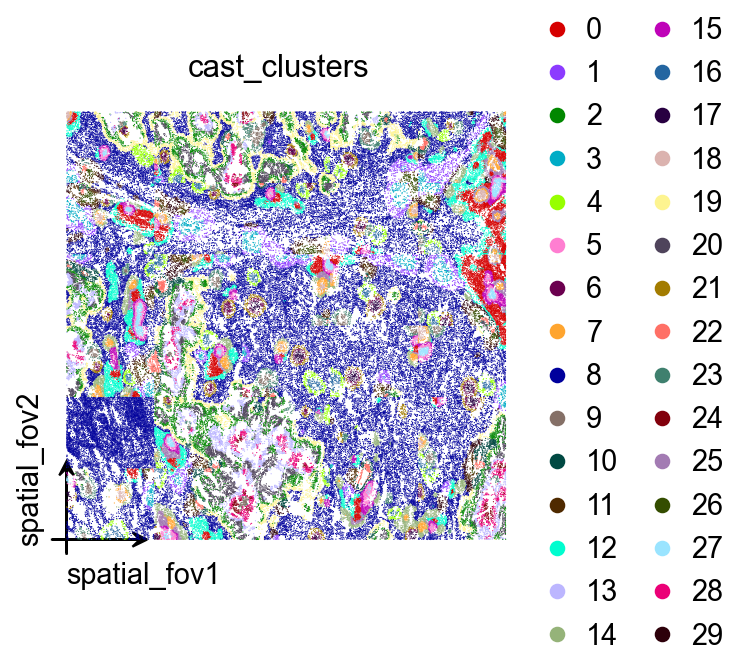

In [99]:
ov.pl.embedding(
    adata,
    basis='spatial_fov',
    color=['cast_clusters'],
    vmax='p99.2',
    cmap='Reds',
    palette=ov.pl.palette_112[:],
    legend_fontsize=13,
)

Earlier, `X_cast` was temporarily stored as a `DataFrame` to make index-based assignment convenient. Before computing the neighborhood graph, it is converted back to a `numpy` array so downstream functions can use it directly.

In [82]:
adata.obsm['X_cast']=adata.obsm['X_cast'].values

## 18. Build a neighborhood graph from the CAST embedding

At this stage, PCA is no longer used. Instead, `X_cast` itself is treated as the representation space for nearest-neighbor graph construction.

### Main parameters

- `n_neighbors=15`: connect each cell to 15 nearest neighbors.
- `n_pcs=512`: here this matches the embedding dimensionality because `X_cast` has 512 dimensions.
- `use_rep='X_cast'`: explicitly tell the function to use the CAST embedding rather than a default representation.

This step turns the learned embedding into a graph structure that can support community detection and other downstream analyses.

In [ ]:
ov.pp.neighbors(
    adata,n_neighbors=15,
    n_pcs=512, use_rep='X_cast',
)

## 19. Run Leiden clustering

Leiden clustering is then applied to the neighborhood graph built from the CAST embedding.

- `resolution=0.1`: controls clustering granularity. Larger values usually produce more clusters, while smaller values give coarser partitions.

Compared with the earlier K-means result, Leiden depends more directly on the neighbor graph structure, so the two sets of clusters are not expected to be identical.

In [88]:
ov.pp.leiden(adata,resolution=0.1)

⚙️ Using torch CPU/GPU mixed mode to calculate Leiden...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA A100-SXM4-40GB
    |----------------------------- 2443/40960 MiB (6.0%)
Using batch size `n_batches` calculated from sqrt(n_obs): 326
Running GPU Leiden (batched)
Device: cpu


Leiden:   0%|          | 0/10 [00:00<?, ?it/s]

L0 Batched(326):   0%|          | 0/100 [00:00<?, ?it/s]

L1 Batched(326):   0%|          | 0/100 [00:00<?, ?it/s]

L2 Batched(326):   0%|          | 0/100 [00:00<?, ?it/s]

L3 Batched(326):   0%|          | 0/100 [00:00<?, ?it/s]

L4 Batched(326):   0%|          | 0/100 [00:00<?, ?it/s]

L5 Batched(326):   0%|          | 0/100 [00:00<?, ?it/s]

L6 Batched(326):   0%|          | 0/100 [00:00<?, ?it/s]

done: 25 clusters (0:00:24)

╭─ SUMMARY: leiden ──────────────────────────────────────────────────╮
│  Duration: 24.0545s                                                │
│  Shape:    106,660 x 980 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯


These Leiden labels are plotted back in `spatial_fov` coordinates so they can be compared directly with the earlier CAST K-means assignments.

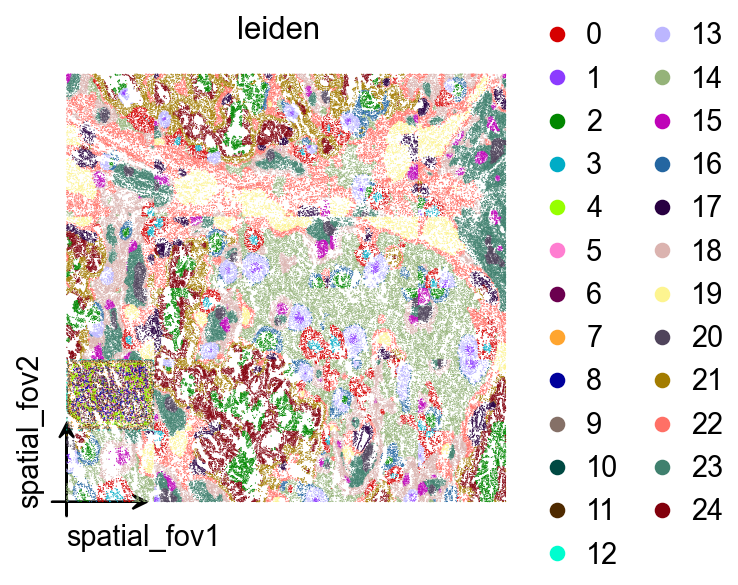

In [89]:
ov.pl.embedding(
    adata,
    basis='spatial_fov',
    color=['leiden'],
    vmax='p99.2',
    cmap='Reds',
    palette=ov.pl.palette_112,
    legend_fontsize=13,
)

## 20. Compare clustering results within a single FOV

Finally, return to `fov == '12'` and overlay both `leiden` and `cast_clusters` on the segmented image.

This is a practical way to answer two common questions:

1. Do cluster boundaries follow tissue structure?
2. Are the local partitions from K-means and Leiden broadly consistent?

If the two results differ strongly in some regions, it is often worth revisiting the embedding quality, graph construction settings, or segmentation context.

In [100]:
vdata=adata[adata.obs['fov']=='12']

This panel shows the spatial distribution of Leiden clusters on the segmentation overlay. Because the boundary lines are kept relatively thin, it is easier to inspect transitions between neighboring cell groups.

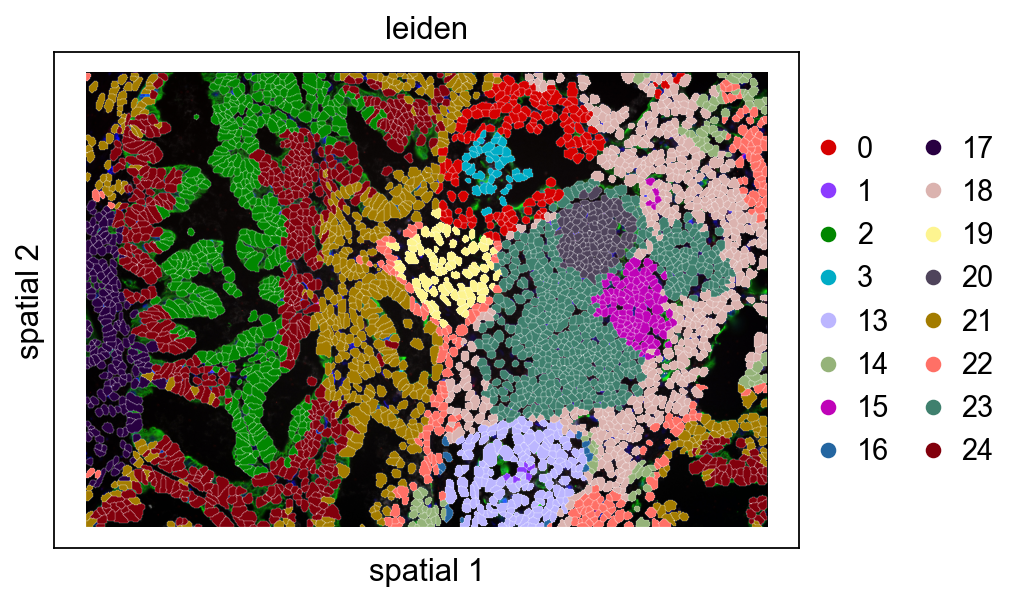

<Axes: title={'center': 'leiden'}, xlabel='spatial 1', ylabel='spatial 2'>

In [104]:
ov.pl.spatialseg(
    vdata,
    color="leiden",
    edges_color='white',
    edges_width=0.1,
    #edges_width=0.4,
    figsize=(7, 4),
    library_id='12',
    alpha_img=1,
    #seg_contourpx=1,
    alpha=1,
    #crop_coord=(0, 0, 1400, 1400),
    legend_fontsize=13,
)

This panel shows the CAST K-means clustering result. Viewed next to the Leiden panel, it helps clarify:

- whether the CAST embedding captures the main spatial structure;
- where local differences between graph-based clustering and direct clustering arise.

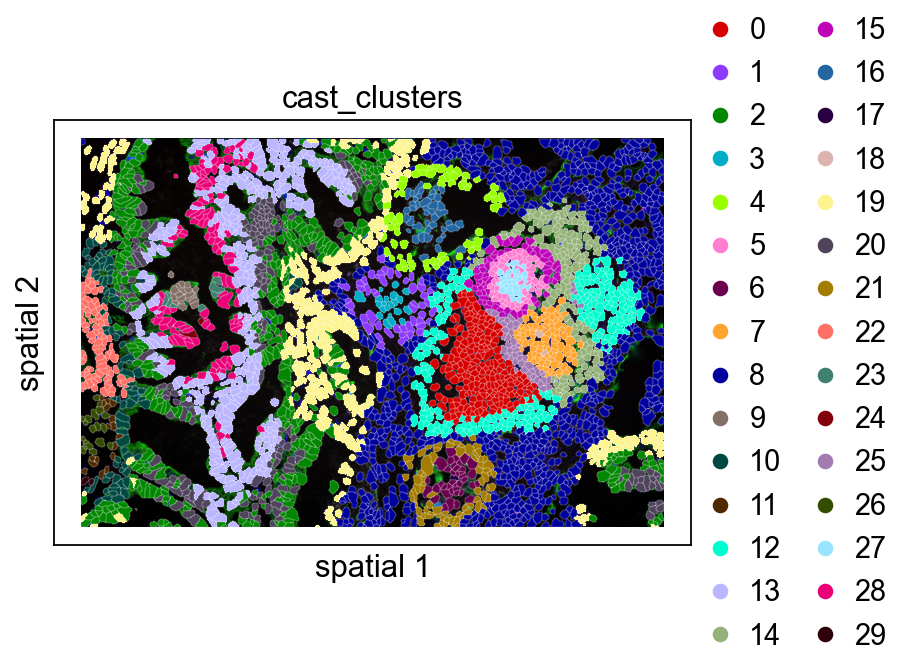

<Axes: title={'center': 'cast_clusters'}, xlabel='spatial 1', ylabel='spatial 2'>

In [105]:
ov.pl.spatialseg(
    vdata,
    color="cast_clusters",
    edges_color='white',
    edges_width=0.1,
    #edges_width=0.4,
    figsize=(7, 4),
    library_id='12',
    alpha_img=1,
    #seg_contourpx=1,
    alpha=1,
    #crop_coord=(0, 0, 1400, 1400),
    legend_fontsize=13,
)

## Summary

At this point, the full workflow is complete:

- read NanoString raw files into an `AnnData` object;
- inspect spatial expression and segmentation at both whole-sample and single-FOV scales;
- prepare CAST inputs and learn graph embeddings;
- perform K-means and Leiden clustering in the embedding space, then map the results back to spatial coordinates.

Natural next steps would include:

- annotating CAST-derived clusters with marker genes;
- comparing clustering consistency across FOVs or biological replicates;
- combining CAST embeddings with more formal downstream analyses such as neighborhood enrichment, differential expression, or region-level annotation.